<a href="https://colab.research.google.com/github/Maryam78-coder/CaptionCraft-AI/blob/main/Image_Caption_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from transformers import BlipProcessor, BlipForConditionalGeneration, CLIPProcessor, CLIPModel
from google.colab import files
from IPython.display import display, Image as IPyImage, FileLink
from tqdm.notebook import tqdm # Import tqdm for progress bar

In [ ]:
# === Load Models ===
# Consider adding error handling for model loading
try:
    blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    print("Models loaded successfully.")
except Exception as e:
    print(f"Error loading models: {e}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Models loaded successfully.


In [ ]:
# === Generate Caption ===
def generate_caption(image_path, processor, model):
    try:
        image = PILImage.open(image_path).convert('RGB')
        inputs = processor(image, return_tensors="pt")
        outputs = model.generate(**inputs)
        caption = processor.decode(outputs[0], skip_special_tokens=True)
        return caption
    except Exception as e:
        print(f"Error generating caption for {image_path}: {e}")
        return "Caption generation failed."

In [ ]:
def score_caption(image_path, caption, clip_processor, clip_model, baseline_caption="a random picture"):
    try:
        image = PILImage.open(image_path).convert("RGB")
        inputs = clip_processor(
            text=[caption, baseline_caption], images=image, return_tensors="pt", padding=True
        )
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image  # shape: [1, 2]
        probs = logits_per_image.softmax(dim=1).detach().cpu().numpy()[0]
        return round(probs[0] * 100, 2)
    except Exception as e:
        print(f"Error scoring caption for {image_path}: {e}")
        return 0.0

In [ ]:
def draw_subtitle_cv2(image_path, caption, score, output_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error loading image for drawing: {image_path}")
            return None, None # Return None for both img and path on failure

        H, W, _ = img.shape
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.8
        thickness = 2

        subtitle = f"{caption} ({score}% match)"
        text_size, _ = cv2.getTextSize(subtitle, font, font_scale, thickness)
        text_width, text_height = text_size

        x = (W - text_width) // 2
        y = H - 30

        # Optional: Draw black border for readability
        cv2.putText(img, subtitle, (x, y), font, font_scale, (0, 0, 0), thickness + 2, cv2.LINE_AA)
        # White text
        cv2.putText(img, subtitle, (x, y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

        cv2.imwrite(output_path, img)
        return img, output_path # Return both img and path on success

    except Exception as e:
        print(f"Error drawing subtitle: {e}")
        return None, None # Return None for both img and path on error

In [ ]:
# === Function to process a single image ===
def process_single_image(image_path, blip_processor, blip_model, clip_processor, clip_model):
    caption = generate_caption(image_path, blip_processor, blip_model)
    score = score_caption(image_path, caption, clip_processor, clip_model)
    output_path = f"/content/captioned_{os.path.basename(image_path)}"

    img, final_output_path = draw_subtitle_cv2(image_path, caption, score, output_path)

    return {
        'image_name': os.path.basename(image_path),
        'caption': caption,
        'score': score,
        'output_path': final_output_path, # Use the path returned by draw_subtitle_cv2
        'processed_image': img # Keep the processed image data in memory if needed later
    }

Please upload images.


Saving image1.jpg to image1 (1).jpg
Saving image3.jpg to image3.jpg
Saving img1.jpg to img1 (1).jpg
Saving img2.jpg to img2 (1).jpg
Saving img3.webp to img3 (1).webp
Output directory created at /content/captioned_images


Processing Images:   0%|          | 0/5 [00:00<?, ?it/s]

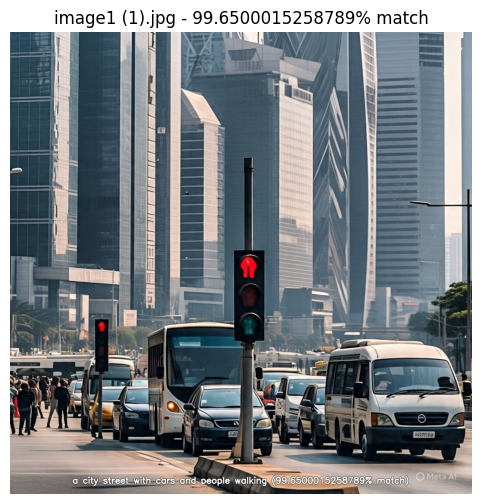

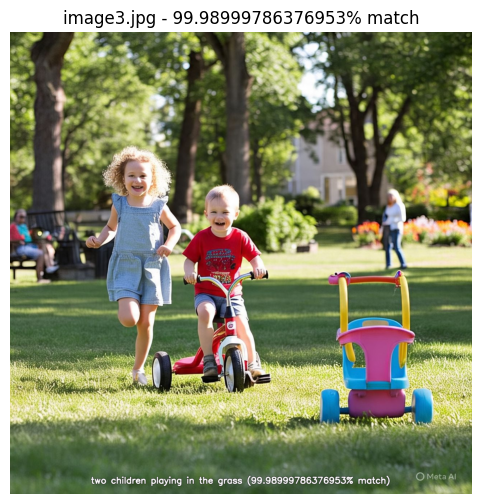

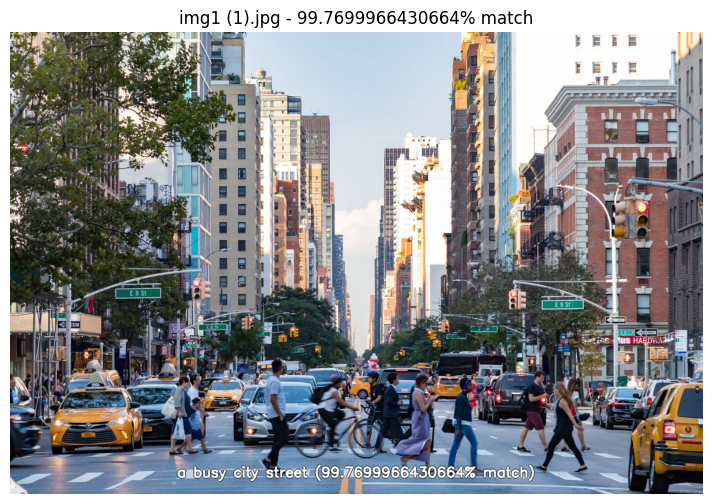

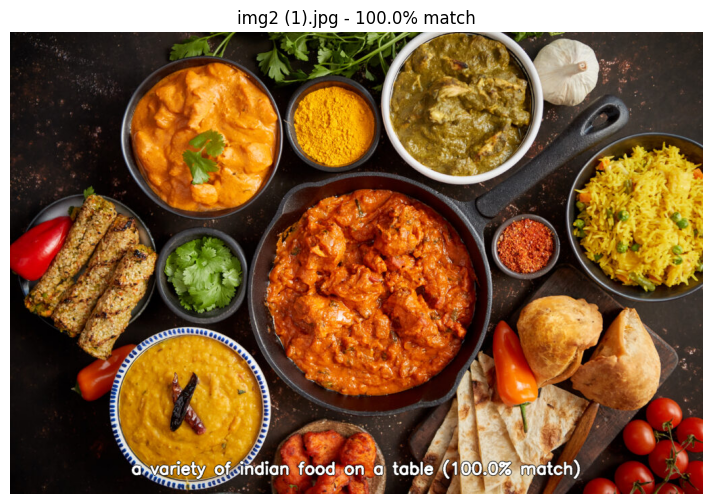

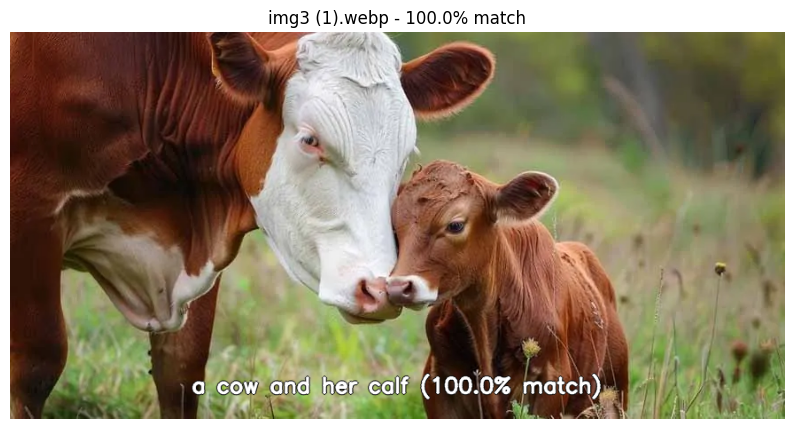

In [ ]:
# === Function to process a single image ===
def process_single_image(image_path, blip_processor, blip_model, clip_processor, clip_model):
    caption = generate_caption(image_path, blip_processor, blip_model)
    score = score_caption(image_path, caption, clip_processor, clip_model)
    output_path = f"/content/captioned_{os.path.basename(image_path)}"

    # Now draw_subtitle_cv2 correctly returns two values or (None, None)
    img, final_output_path = draw_subtitle_cv2(image_path, caption, score, output_path)

    return {
        'image_name': os.path.basename(image_path),
        'caption': caption,
        'score': score,
        'output_path': final_output_path, # Use the path returned by draw_subtitle_cv2
        'processed_image': img # Keep the processed image data in memory if needed later
    }

# === Upload Multiple Images ===
print("Please upload images.")
uploaded = files.upload()

captions = []
scores = []
image_names = []
output_paths = []
processed_images = [] # Revert to original name to match the code block's usage later
# Create output directory if it doesn't exist
output_dir = "/content/captioned_images"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created at {output_dir}")
# === Process Each Image ===
# Use tqdm to show progress for the loop
for image_path in tqdm(uploaded.keys(), desc="Processing Images"):
    image_data = process_single_image(image_path, blip_processor, blip_model, clip_processor, clip_model)

    if image_data['processed_image'] is not None:
        image_names.append(image_data['image_name'])
        captions.append(image_data['caption'])
        scores.append(image_data['score'])
        output_paths.append(image_data['output_path'])
        # Append the processed image data to the list
        processed_images.append(image_data['processed_image'])

        # Show image
        plt.figure(figsize=(10, 6))
        plt.axis('off')
        plt.title(f"{image_data['image_name']} - {image_data['score']}% match")
        # Display the image from the processed_images list
        # Ensure the image data is in the correct format (BGR to RGB for matplotlib)
        plt.imshow(cv2.cvtColor(image_data['processed_image'], cv2.COLOR_BGR2RGB))
        plt.show()
    else:
        print(f"Skipping display and saving for {image_data['image_name']} due to processing errors.")

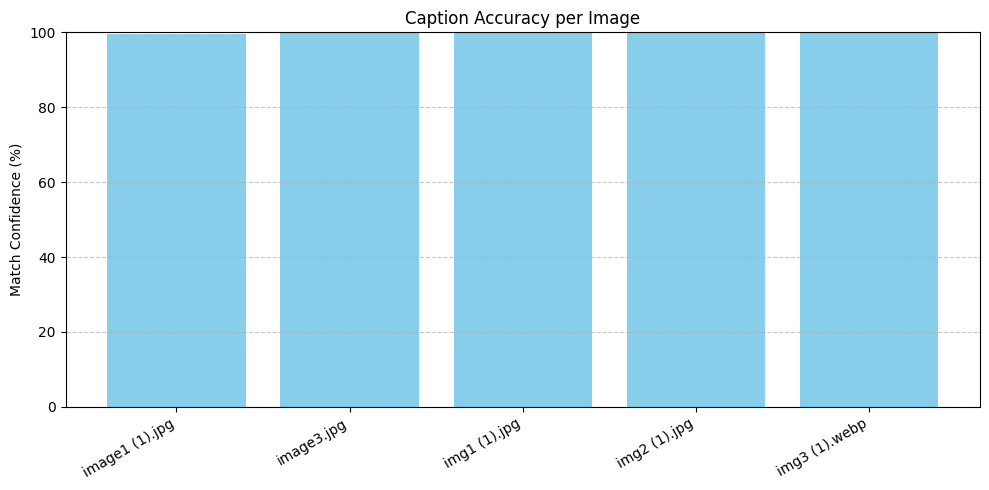

In [ ]:
# === Bar Chart for All Images ===
if image_names: # Check if there are any successfully processed images
    plt.figure(figsize=(10, 5))
    plt.bar(image_names, scores, color='skyblue')
    plt.ylabel("Match Confidence (%)")
    plt.ylim(0, 100)
    plt.title("Caption Accuracy per Image")
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No images processed successfully to generate bar chart.")

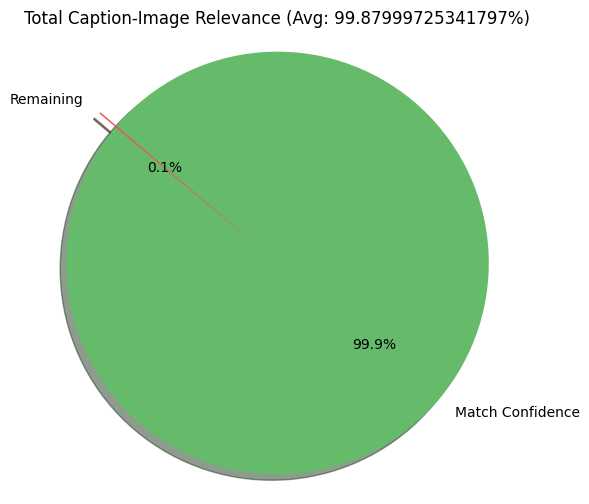

In [ ]:
# === Pie Chart: Total Match vs. Unmatch ===
if scores: # Check if there are any scores
    total_score = sum(scores)
    avg_score = round(total_score / len(scores), 2)
    remaining = 100 * len(scores) - total_score

    plt.figure(figsize=(6, 6))
    labels = ['Match Confidence', 'Remaining']
    sizes = [total_score, remaining]
    colors = ['#66bb6a', '#ef5350']
    explode = (0.1, 0)

    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            explode=explode, shadow=True, startangle=140)
    plt.title(f'Total Caption-Image Relevance (Avg: {avg_score}%)')
    plt.axis('equal')
    plt.show()
else:
    print("No scores available to generate pie chart.")

In [ ]:
# === Download Captioned Images ===
if output_paths: # Check if there are any output paths
    print("Downloading captioned images...")
    for path in tqdm(output_paths, desc="Downloading Images"):
        try:
            files.download(path)
        except Exception as e:
            print(f"Error downloading {path}: {e}")
else:
    print("No captioned images to download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>